<a href="https://colab.research.google.com/github/Astronom2617/rossmann-sales-forecasting/blob/main/rossmann_sarima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train = pd.read_csv('/content/drive/MyDrive/rossmann/train.csv',
                    parse_dates=['Date'], low_memory=False)
store = pd.read_csv('/content/drive/MyDrive/rossmann/store.csv')
test = pd.read_csv('/content/drive/MyDrive/rossmann/test.csv',
                   parse_dates=['Date'])

In [3]:
store1 = train[train['Store'] == 1].sort_values('Date')
store1 = store1[store1['Open'] == 1]
store1 = store1.set_index('Date')['Sales']
store1.head(10)

,Sales
Date,
2013-01-02,5530
2013-01-03,4327
2013-01-04,4486
2013-01-05,4997
2013-01-07,7176
2013-01-08,5580
2013-01-09,5471
2013-01-10,4892
2013-01-11,4881


In [5]:
result = adfuller(store1)
print(result)

(np.float64(-5.399623337824008), np.float64(3.3933795244319574e-06), 13, 767, {'1%': np.float64(-3.4389045244994096), '5%': np.float64(-2.8653156040031176), '10%': np.float64(-2.5687805115003)}, np.float64(12087.816830039481))


In [6]:
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.6f}')
print('Conclusion: Stationary ✓' if result[1] < 0.05 else 'Conclusion: Not Stationary ✗')

ADF Statistic: -5.3996
p-value: 0.000003
Conclusion: Stationary ✓


### 1. Conclusion about Stationarity
Our time series is stationary because we performed the Augmented Dickey-Fuller test and got p-value: 0.000003 < 0.05, which means that our series is stationary and we can apply ARIMA

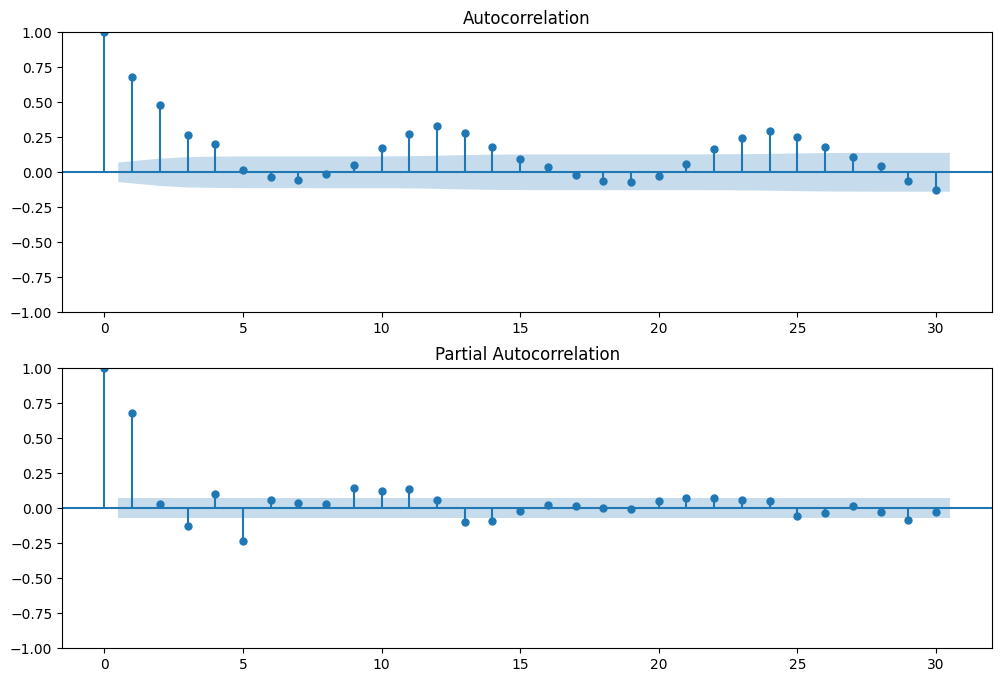

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12,8))
plot_acf(store1, lags=30, ax=axes[0])
plot_pacf(store1, lags=30, ax=axes[1])
plt.show()

### 2. Conclusion about ACF and PACF
As we can see from the ACF graph, we have seasonality every 7 lags, that is, weekly seasonality. For q, we'll take 1 because decay begins after lag 1. For p, we'll take 2 because the graph breaks off immediately after lag 2.